In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.dates as mdates
from scipy.stats import skew
from scipy.stats.stats import pearsonr
from math import sqrt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

C:\Users\DELL\AppData\Local\Temp\ipykernel_18308\3857781209.py:9: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [ ]:
df_sales = pd.read_csv(r'D:\rossmann-store-sales\sale.csv', parse_dates = True, low_memory = False, index_col = 'Date')
df_stores = pd.read_csv(r'D:\rossmann-store-sales\store.csv', low_memory = False)

1. Bộ dữ liệu Sales

In [ ]:
df_sales.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [ ]:
df_sales.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [ ]:
df_sales.shape

(1017209, 8)

In [ ]:
df_sales.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


Kiểm tra Missing Values của bộ Sales

In [ ]:
df_sales.isnull().sum()

Store            0
DayOfWeek        0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

2. Tiền xử lý bộ dữ liệu Store

In [ ]:
df_stores.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
df_stores.shape

(1115, 10)

In [ ]:
df_stores.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [ ]:
df_stores.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

- Nhận thấy rằng chỉ có 3 mẫu trong biến CompetitionDistance là bị missing, ta xử lý nó bằng cách fill giá trị trung bình của biến CompetitionDistance

In [ ]:
df_stores['CompetitionDistance'].fillna(df_stores['CompetitionDistance'].mean(), inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_18308\1828173554.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_stores['CompetitionDistance'].fillna(df_stores['CompetitionDistance'].mean(), inplace = True)


Những mẫu nào không có giá trị trong biến Promo2 thì ta sẽ fill bằng 0

In [ ]:
df_stores.fillna(0, inplace = True)

In [ ]:
df_stores.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


Sau đó, ta tiến hành Join 2 bộ dữ liệu lại với nhau theo biến Store

In [ ]:
df_sales = df_sales.reset_index()
df = df_sales.merge(right=df_stores, on='Store', how='left')

In [ ]:
df.head()

,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,2015-07-31,1,5,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2015-07-31,2,5,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,2015-07-31,3,5,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,2015-07-31,4,5,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,2015-07-31,5,5,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


EDA

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

# Lấy các ngày có Sales > 0 (cửa hàng mở)
df_open = df[df['Sales'] > 0].copy()

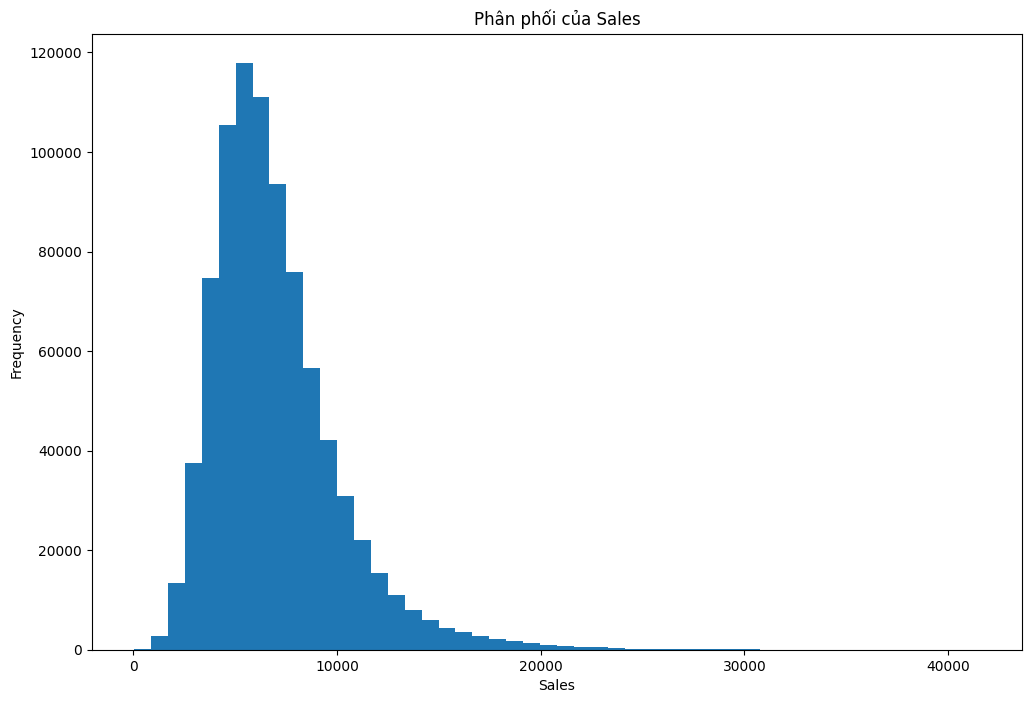

In [ ]:
plt.figure(figsize=(12, 8))
plt.hist(df_open['Sales'], bins=50)
plt.title('Phân phối của Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

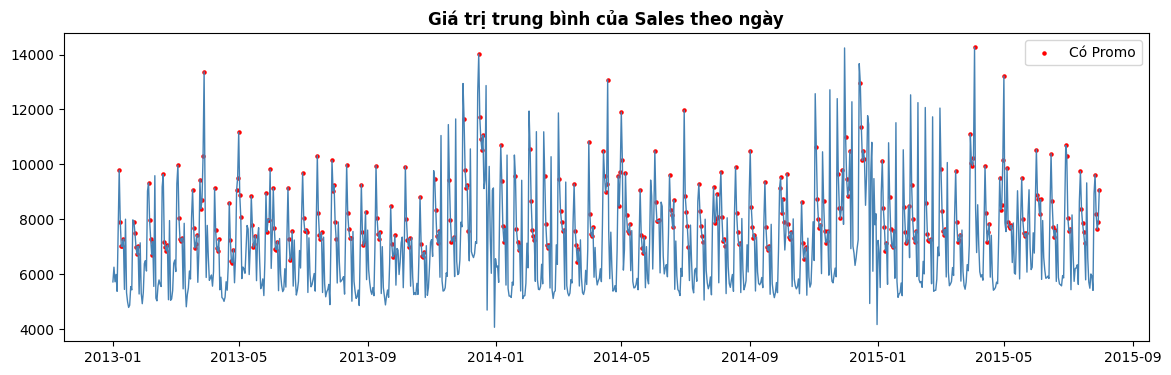

In [ ]:
# Giá trị trung bình của Sales theo ngày
daily = df_open.groupby('Date')['Sales'].mean()
promo_days = df_open[df_open['Promo'] == 1].groupby('Date')['Sales'].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily.index, daily.values, color='steelblue', linewidth=1)
plt.scatter(promo_days.index, promo_days.values, color='red', s=5, label='Có Promo')
plt.title('Giá trị trung bình của Sales theo ngày', weight = 'bold')
plt.legend()
plt.show()

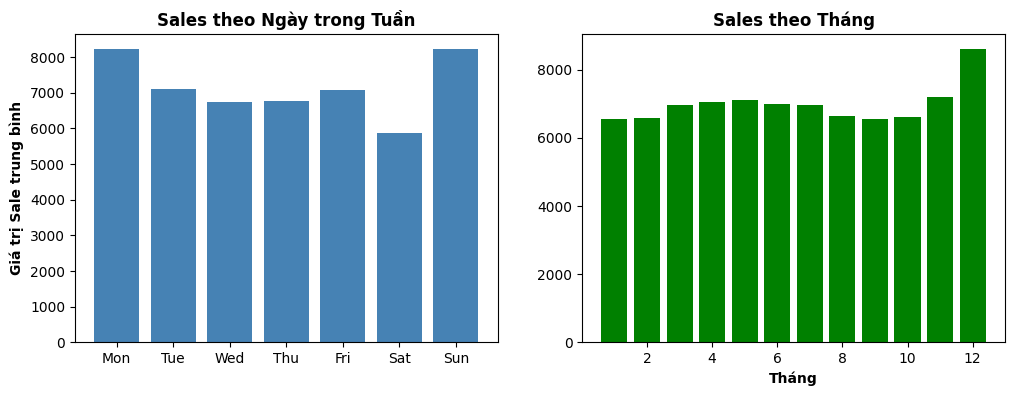

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dow = df_open.groupby('DayOfWeek')['Sales'].mean()
axes[0].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow.values, color='steelblue')
axes[0].set_title('Sales theo Ngày trong Tuần', weight = 'bold')
axes[0].set_ylabel('Giá trị Sale trung bình', weight = 'bold')

month = df_open.groupby(df_open['Date'].dt.month)['Sales'].mean()
axes[1].bar(range(1, 13), month.values, color='green')
axes[1].set_title('Sales theo Tháng', weight = 'bold')
axes[1].set_xlabel('Tháng', weight = 'bold')

plt.show()

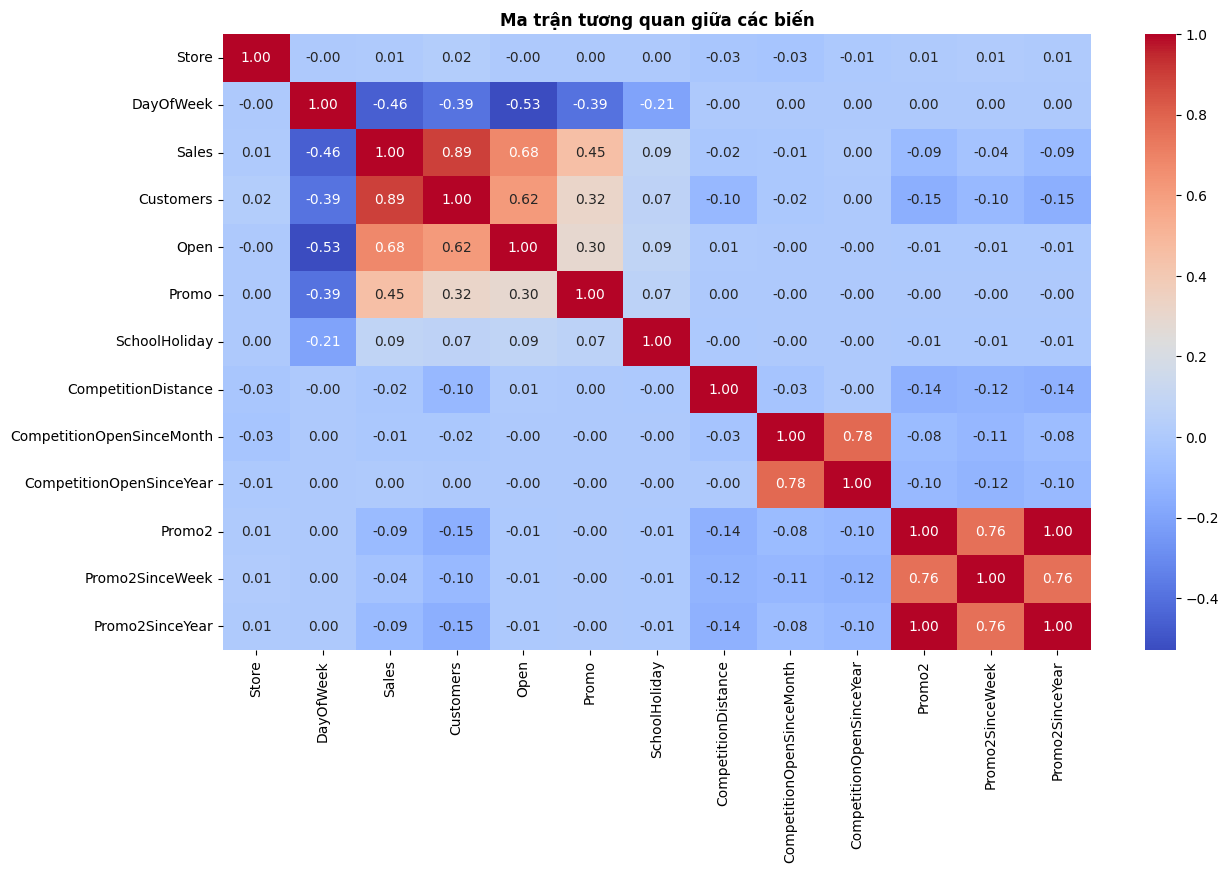

Customers                    0.894711
Open                         0.678472
Promo                        0.452345
SchoolHoliday                0.085124
Store                        0.005126
CompetitionOpenSinceYear     0.002749
CompetitionOpenSinceMonth   -0.012431
CompetitionDistance         -0.019207
Promo2SinceWeek             -0.044143
Promo2                      -0.091040
Promo2SinceYear             -0.091056
DayOfWeek                   -0.462125
Name: Sales, dtype: float64


In [ ]:
# Tương quan giữa các biến
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Ma trận tương quan giữa các biến', weight = 'bold')
plt.show()

print(corr['Sales'].drop('Sales').sort_values(ascending=False))

Feature Engineering

In [ ]:

# FEATURE ENGINEERING - CLEAN VERSION (MODEL COMPARISON READY)


import numpy as np
import pandas as pd

# 1. SORT + DATETIME
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by=['Store', 'Date']).reset_index(drop=True)


# 2. TIME FEATURES

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1
df['IsWeekend'] = df['DayOfWeek'].isin([6,7]).astype(int)

# 3. LAG FEATURES

lags = [1, 3, 7, 14]

for lag in lags:
    df[f'Sales_lag_{lag}'] = df.groupby('Store')['Sales'].shift(lag)
    df[f'Customers_lag_{lag}'] = df.groupby('Store')['Customers'].shift(lag)


# 4. ROLLING FEATURES

windows = [7, 14]

for w in windows:
    df[f'Sales_roll_mean_{w}'] = df.groupby('Store')['Sales']\
        .transform(lambda x: x.shift(1).rolling(window=w).mean())

    df[f'Sales_roll_std_{w}'] = df.groupby('Store')['Sales']\
        .transform(lambda x: x.shift(1).rolling(window=w).std())

    df[f'Sales_roll_max_{w}'] = df.groupby('Store')['Sales']\
        .transform(lambda x: x.shift(1).rolling(window=w).max())


# 5. INTERACTION FEATURES

df['Promo_Weekend'] = df['Promo'] * df['IsWeekend']
df['Promo_Month'] = df['Promo'] * df['Month']

# tránh chia 0 sạch hơn
df['Sales_per_Customer'] = df['Sales'] / df['Customers'].replace(0, np.nan)


# 6. ONE-HOT DAY OF WEEK

df = pd.get_dummies(df, columns=['DayOfWeek'], prefix='DOW')


# 7. HANDLE NaN


shape_before = df.shape

# Drop các dòng chưa đủ lịch sử
df = df.dropna()

df = df.reset_index(drop=True)

print(f"Shape trước xử lý: {shape_before}")
print(f"Shape sau xử lý: {df.shape}")

Shape trước xử lý: (1017209, 45)
Shape sau xử lý: (832114, 45)


In [ ]:
categorical_cols = ['StateHoliday', 'StoreType', 'Assortment']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
df = df.sort_values(by='Date')

In [ ]:
exclude_cols = [
    'Date',
    'Sales',
    'Customers',
    'PromoInterval',
    'Store'
]

features = [col for col in df.columns if col not in exclude_cols]

X = df[features]
y = df['Sales']

print("Số features:", len(features))
print(features)

Số features: 45
['Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'WeekOfYear', 'IsWeekend', 'Sales_lag_1', 'Customers_lag_1', 'Sales_lag_3', 'Customers_lag_3', 'Sales_lag_7', 'Customers_lag_7', 'Sales_lag_14', 'Customers_lag_14', 'Sales_roll_mean_7', 'Sales_roll_std_7', 'Sales_roll_max_7', 'Sales_roll_mean_14', 'Sales_roll_std_14', 'Sales_roll_max_14', 'Promo_Weekend', 'Promo_Month', 'Sales_per_Customer', 'DOW_1', 'DOW_2', 'DOW_3', 'DOW_4', 'DOW_5', 'DOW_6', 'DOW_7', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_b', 'Assortment_c']


In [ ]:
# df.to_csv("dataset.csv", index=False)

Huấn luyện Models

In [ ]:
# Split 80/20
# 4. Chia bộ dữ liệu huấn luyện
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Số mẫu train: {X_train.shape[0]}")
print(f"Số mẫu test: {X_test.shape[0]}")

Số mẫu train: 665691
Số mẫu test: 166423


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import numpy as np


# 1. Lấy sample
# dùng .loc để tránh overhead không cần thiết
X_tune = X_train.sample(frac=0.2, random_state=42)
y_tune = y_train.loc[X_tune.index]


# 2. RandomForest

rf_params = {
    'n_estimators':      [100, 150],   # giảm nhẹ
    'max_depth':         [6, 8, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=5,                       # giảm 1/2
    scoring='neg_root_mean_squared_error',
    cv=2,
    random_state=42,
    n_jobs=1,
    verbose=1
)

rf_search.fit(X_tune, y_tune)
print("RF best params:", rf_search.best_params_)


# 3. XGBoost (giảm tải mạnh)

xgb_params = {
    'n_estimators':     [100, 150, 200],
    'max_depth':        [4, 6],
    'learning_rate':    [0.05, 0.1],
    'subsample':        [0.8],
    'colsample_bytree': [0.8],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(
        random_state=42,
        tree_method='hist',
        eval_metric='rmse',
        n_jobs=1
    ),
    param_distributions=xgb_params,
    n_iter=5,
    scoring='neg_root_mean_squared_error',
    cv=2,
    random_state=42,
    n_jobs=1,
    verbose=1
)

xgb_search.fit(X_tune, y_tune)
print("XGB best params:", xgb_search.best_params_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
RF best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
Fitting 2 folds for each of 5 candidates, totalling 10 fits
XGB best params: {'subsample': 0.8, 'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [ ]:
# 5. TRAIN 3 MODELS
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        **rf_search.best_params_, random_state=42
    ),
    "XGBoost": XGBRegressor(
        **xgb_search.best_params_, random_state=42
    ),
}

results = {}
predictions = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    models[name] = model
    preds = model.predict(X_test)
    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results[name] = {"MAE": mae, "RMSE": rmse}

    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")


Training LinearRegression...
LinearRegression → MAE: 839.85, RMSE: 1181.30

Training RandomForest...
RandomForest → MAE: 697.43, RMSE: 1014.67

Training XGBoost...
XGBoost → MAE: 561.15, RMSE: 823.96


In [ ]:
# 6. TẠO BẢNG SO SÁNH DỰ BÁO (5 DÒNG ĐẦU)
compare_df = pd.DataFrame({
    "Actual": y_test.values,
    "LinearRegression": predictions["LinearRegression"],
    "RandomForest": predictions["RandomForest"],
    "XGBoost": predictions["XGBoost"]
})

print("\nSo sánh 5 dòng random:")
print(compare_df.sample(5, random_state=42))


So sánh 5 dòng random:
       Actual  LinearRegression  RandomForest      XGBoost
8091     6758       8574.558613   7670.786873  7487.443359
95916    9243       9512.903003  10827.608137  9903.957031
55164    8487       7048.322130   7453.586385  7536.506836
46524    5347       5495.893035   5103.349278  5190.372559
97853    7783       8791.418060   8037.617806  8096.311035


In [ ]:
# 6. CHỌN MODEL TỐT NHẤT

results_df = pd.DataFrame(results).T
print("\nModel Comparison:")
print(results_df.sort_values("RMSE"))

best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]
model = best_model

print(f"\nModel có chỉ số dự báo tốt nhất: {best_model_name}")


Model Comparison:
                         MAE         RMSE
XGBoost           561.154655   823.959475
RandomForest      697.428408  1014.668029
LinearRegression  839.852879  1181.296238

Model có chỉ số dự báo tốt nhất: XGBoost


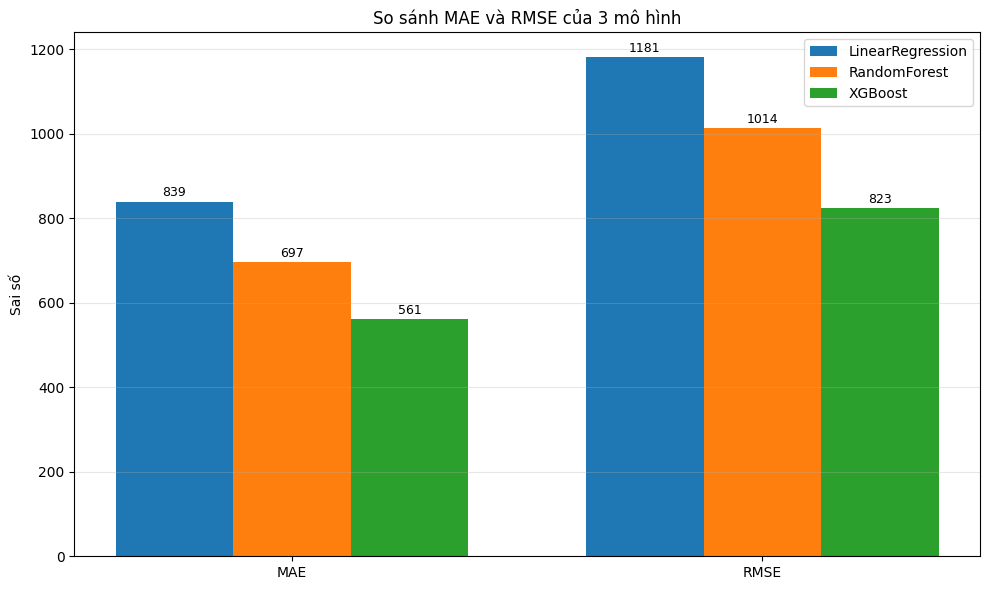

In [ ]:
results_df = pd.DataFrame(results).T

x = np.arange(2)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for idx, name in enumerate(results_df.index):
    vals = [results_df.loc[name, 'MAE'], results_df.loc[name, 'RMSE']]
    bars = ax.bar(x + idx * width, vals, width, label=name)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(val)}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(['MAE', 'RMSE'])
ax.set_title('So sánh MAE và RMSE của 3 mô hình')
ax.set_ylabel('Sai số')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# 7. USER INPUT

min_id = df["Store"].min()
max_id = df["Store"].max()

while True:
    try:
        user_input = input(f"\n Vui lòng nhập ID của Cửa Hàng ({min_id}-{max_id}): ")
        store_id = int(user_input)

        if store_id not in df["Store"].values:
            print(f"Cửa hàng số {store_id} không tồn tại trong hệ thống! Vui lòng nhập lại.")
            continue

        store_df = df[df["Store"] == store_id].copy().sort_values("Date")

        if len(store_df) < 20:
            print(f"Cửa hàng số {store_id} không có đủ dữ liệu lịch sử. Vui lòng chọn ID khác!")
            continue

        print(f"Đã tải thành công dữ liệu của Cửa Hàng {store_id}!")
        break

    except ValueError:
        print("Lỗi: Ký tự không hợp lệ. Vui lòng chỉ nhập SỐ NGUYÊN!")


# 8. CREATE FUTURE

import matplotlib.dates as mdates

future_dates = pd.date_range(start="2015-08-01", end="2015-09-17")
hist_df_full = store_df.copy()

df_future_base = pd.DataFrame({"Date": future_dates})
df_future_base["Store"]         = store_id
df_future_base["Sales"]         = np.nan
df_future_base["Customers"]     = np.nan
df_future_base["Promo"]         = 0
df_future_base["StateHoliday"]  = 0
df_future_base["SchoolHoliday"] = 0

df_future_base["Year"]       = df_future_base["Date"].dt.year
df_future_base["Month"]      = df_future_base["Date"].dt.month
df_future_base["WeekOfYear"] = df_future_base["Date"].dt.isocalendar().week.astype(int)
_dow_f = df_future_base["Date"].dt.dayofweek + 1
df_future_base["IsWeekend"]     = _dow_f.isin([6, 7]).astype(int)
df_future_base["Promo_Weekend"] = df_future_base["Promo"] * df_future_base["IsWeekend"]
df_future_base["Promo_Month"]   = df_future_base["Promo"] * df_future_base["Month"]

df_future_base["_DOW_tmp"] = _dow_f
df_future_base = pd.get_dummies(df_future_base, columns=["_DOW_tmp"], prefix="DOW")
for d in range(1, 8):
    col = f"DOW_{d}"
    if col not in df_future_base.columns:
        df_future_base[col] = 0

for col in features:
    if col not in df_future_base.columns:
        if col in hist_df_full.columns:
            df_future_base[col] = hist_df_full[col].iloc[0]
        else:
            df_future_base[col] = 0

lag_roll_cols = [c for c in features if "lag" in c or "roll" in c or c == "Sales_per_Customer"]
for col in lag_roll_cols:
    df_future_base[col] = np.nan

full_df = pd.concat([hist_df_full, df_future_base], ignore_index=True)
full_df = full_df.sort_values("Date").reset_index(drop=True)

future_start_idx = full_df[full_df["Date"] == pd.Timestamp("2015-08-01")].index[0]

_tmp = hist_df_full.copy()
_tmp["_dow"] = _tmp["Date"].dt.dayofweek + 1
cust_dow_avg = _tmp.groupby("_dow")["Customers"].mean().to_dict()


# HELPER: Fill lag/rolling

def fill_lag_rolling(df_ref, i):
    for lag in [1, 3, 7, 14]:
        idx = i - lag
        df_ref.loc[i, f"Sales_lag_{lag}"]     = df_ref.loc[idx, "Sales"] if idx >= 0 else np.nan
        val = df_ref.loc[idx, "Customers"] if idx >= 0 else np.nan
        if pd.isna(val):
            val = cust_dow_avg.get(df_ref.loc[i, "Date"].dayofweek + 1, 0)
        df_ref.loc[i, f"Customers_lag_{lag}"] = val

    for w in [7, 14]:
        history = df_ref.loc[max(0, i - w): i - 1, "Sales"].dropna()
        df_ref.loc[i, f"Sales_roll_mean_{w}"] = history.mean() if len(history) > 0 else np.nan
        df_ref.loc[i, f"Sales_roll_std_{w}"]  = history.std()  if len(history) > 1 else 0.0
        df_ref.loc[i, f"Sales_roll_max_{w}"]  = history.max()  if len(history) > 0 else np.nan

    s_lag1 = df_ref.loc[i, "Sales_lag_1"]
    c_lag1 = df_ref.loc[i, "Customers_lag_1"]
    df_ref.loc[i, "Sales_per_Customer"] = (
        s_lag1 / c_lag1 if (not pd.isna(s_lag1) and not pd.isna(c_lag1) and c_lag1 != 0)
        else hist_df_full["Sales_per_Customer"].median()
    )


# HELPER: Vẽ biểu đồ dùng chung

def plot_forecast(store_id, plot_hist_df, df_future, pred_no_promo, avg_sales,
                  df_promo_predicted=None, pred_with_promo=None,
                  days_on=None, days_off=None):

    plt.style.use("dark_background")
    fig, ax = plt.subplots(figsize=(16, 8))

    color_actual   = "#00e5ff"
    color_baseline = "#ffaa00"
    color_promo    = "#39ff14"
    color_avg      = "#ff0055"
    color_grid     = "#444444"

    ax.plot(plot_hist_df["Date"], plot_hist_df["Sales"],
            linestyle="-", marker="o", markersize=5, color=color_actual,
            linewidth=2, label="Actual Demand (Last 60 days)")
    ax.fill_between(plot_hist_df["Date"], plot_hist_df["Sales"],
                    color=color_actual, alpha=0.15)

    ax.plot(df_future["Date"], pred_no_promo,
            linestyle="--", marker=".", markersize=4, color=color_baseline,
            linewidth=1.5, alpha=0.8, label="Forecast (No Promo)")

    if df_promo_predicted is not None and pred_with_promo is not None:
        ax.plot(df_promo_predicted["Date"], pred_with_promo,
                linestyle="-", marker="o", markersize=5, color=color_promo,
                linewidth=2.5, label=f"Forecasted Demand (Promo {days_on} On / {days_off} Off)")
        ax.fill_between(df_promo_predicted["Date"], pred_with_promo,
                        color=color_promo, alpha=0.15)

    ax.axhline(avg_sales, linestyle=":", color=color_avg, linewidth=2,
               label=f"Avg Historical Sales ({avg_sales:,.0f} €)")

    ax.axvspan(df_future["Date"].min(), df_future["Date"].max(), color="#ffffff", alpha=0.03)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")
    ax.grid(color=color_grid, linestyle="--", linewidth=0.5, alpha=0.7)
    ax.tick_params(colors="white", labelsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b \'%y"))
    plt.xticks(rotation=0)

    title_suffix = "with Promo Scenario" if df_promo_predicted is not None else "Baseline (No Promo)"
    plt.title(f"Store {store_id} - Forecast vs Actual Demand | {title_suffix}",
              color="white", fontsize=18, fontweight="bold", pad=20)
    plt.xlabel("Date", color="#aaaaaa", fontsize=12, labelpad=10)
    plt.ylabel("Sales", color="#aaaaaa", fontsize=12, labelpad=10)
    plt.legend(loc="upper left", frameon=True, facecolor="#111111",
               edgecolor="#444444", labelcolor="white", fontsize=11, framealpha=0.85)
    plt.tight_layout()
    plt.show()
    plt.style.use("default")


# 9. FORECAST BASELINE

print("\n Đang chạy dự báo đệ quy (Baseline)...")

for i in range(future_start_idx, len(full_df)):
    fill_lag_rolling(full_df, i)
    X_current = full_df.loc[[i], features].copy()
    if X_current.isnull().any().any():
        for col in X_current.columns[X_current.isnull().any()].tolist():
            X_current[col] = X_current[col].fillna(
                hist_df_full[col].median() if col in hist_df_full.columns else 0)
    pred_sales = max(0, model.predict(X_current)[0])
    full_df.loc[i, "Sales"]     = pred_sales
    full_df.loc[i, "Customers"] = cust_dow_avg.get(full_df.loc[i, "Date"].dayofweek + 1, 0)

df_future_predicted = full_df[full_df["Date"] >= "2015-08-01"].copy()
pred_no_promo = df_future_predicted["Sales"].values
df_future     = df_future_predicted
avg_sales     = hist_df_full["Sales"].mean()

print(f" Avg historical: {avg_sales:.2f}")
print(f" Forecast (no promo): {pred_no_promo.mean():.2f}")

# BIỂU ĐỒ 1: Lịch sử + Baseline
plot_forecast(
    store_id      = store_id,
    plot_hist_df  = hist_df_full.tail(60),
    df_future     = df_future,
    pred_no_promo = pred_no_promo,
    avg_sales     = avg_sales
)


# 10. USER CHỌN PROMO

choice = input("\n Bật Promo cho tháng 8 & 9? (y/n): ")

if choice.lower() == "y":
    print("\n Đang phân tích thói quen chạy Promo trong lịch sử của cửa hàng...")

    streaks = hist_df_full["Promo"].groupby(
        (hist_df_full["Promo"] != hist_df_full["Promo"].shift()).cumsum()
    ).agg(["first", "count"])

    try:
        suggested_on  = int(streaks[streaks["first"] == 1]["count"].mode().iloc[0])
        suggested_off = int(streaks[streaks["first"] == 0]["count"].mode().iloc[0])
    except:
        suggested_on, suggested_off = 5, 9

    print(f" GỢI Ý HỆ THỐNG: Chu kỳ đề xuất: {suggested_on} ngày BẬT, {suggested_off} ngày TẮT.")
    print("1. Chạy theo chu kỳ Gợi ý")
    print("2. Tự thiết lập chu kỳ tùy chỉnh")

    cycle_choice = input(" Bạn chọn kịch bản nào? (1/2): ")

    if cycle_choice == "1":
        days_on, days_off = suggested_on, suggested_off
        print(f" Đã áp dụng: {days_on} ngày BẬT, {days_off} ngày TẮT.")
    else:
        try:
            days_on  = int(input(" Nhập số ngày chạy Promo liên tục (VD: 5): "))
            days_off = int(input(" Nhập số ngày nghỉ Promo (VD: 9): "))
            print(f" Đã áp dụng chu kỳ của bạn: {days_on} ngày BẬT, {days_off} ngày TẮT.")
        except ValueError:
            print(" Lỗi nhập liệu. Tự động áp dụng chu kỳ gợi ý.")
            days_on, days_off = suggested_on, suggested_off

    print("\n Đang chạy dự báo đệ quy kịch bản CÓ PROMO...")

    cycle_pattern = [1] * days_on + [0] * days_off
    full_pattern  = (cycle_pattern * (len(future_dates) // len(cycle_pattern) + 1))[:len(future_dates)]

    df_future_promo = pd.DataFrame({"Date": future_dates})
    df_future_promo["Store"]         = store_id
    df_future_promo["Sales"]         = np.nan
    df_future_promo["Customers"]     = np.nan
    df_future_promo["Promo"]         = full_pattern
    df_future_promo["StateHoliday"]  = 0
    df_future_promo["SchoolHoliday"] = 0

    df_future_promo["Year"]       = df_future_promo["Date"].dt.year
    df_future_promo["Month"]      = df_future_promo["Date"].dt.month
    df_future_promo["WeekOfYear"] = df_future_promo["Date"].dt.isocalendar().week.astype(int)
    _dow_p = df_future_promo["Date"].dt.dayofweek + 1
    df_future_promo["IsWeekend"]     = _dow_p.isin([6, 7]).astype(int)
    df_future_promo["Promo_Weekend"] = df_future_promo["Promo"] * df_future_promo["IsWeekend"]
    df_future_promo["Promo_Month"]   = df_future_promo["Promo"] * df_future_promo["Month"]

    df_future_promo["_DOW_tmp"] = _dow_p
    df_future_promo = pd.get_dummies(df_future_promo, columns=["_DOW_tmp"], prefix="DOW")
    for d in range(1, 8):
        col = f"DOW_{d}"
        if col not in df_future_promo.columns:
            df_future_promo[col] = 0

    for col in features:
        if col not in df_future_promo.columns:
            df_future_promo[col] = hist_df_full[col].iloc[0] if col in hist_df_full.columns else 0

    for col in lag_roll_cols:
        df_future_promo[col] = np.nan

    full_df_promo = pd.concat([hist_df_full, df_future_promo], ignore_index=True)
    full_df_promo = full_df_promo.sort_values("Date").reset_index(drop=True)

    for i in range(future_start_idx, len(full_df_promo)):
        fill_lag_rolling(full_df_promo, i)
        X_current = full_df_promo.loc[[i], features].copy()
        if X_current.isnull().any().any():
            for col in X_current.columns[X_current.isnull().any()].tolist():
                X_current[col] = X_current[col].fillna(
                    hist_df_full[col].median() if col in hist_df_full.columns else 0)
        pred_sales = max(0, model.predict(X_current)[0])
        full_df_promo.loc[i, "Sales"]     = pred_sales
        full_df_promo.loc[i, "Customers"] = cust_dow_avg.get(full_df_promo.loc[i, "Date"].dayofweek + 1, 0)

    df_promo_predicted = full_df_promo[full_df_promo["Date"] >= "2015-08-01"].copy()
    pred_with_promo    = df_promo_predicted["Sales"].values

    #BIỂU ĐỒ 2: Lịch sử + Baseline + Promo
    plot_forecast(
        store_id           = store_id,
        plot_hist_df       = hist_df_full.tail(60),
        df_future          = df_future,
        pred_no_promo      = pred_no_promo,
        avg_sales          = avg_sales,
        df_promo_predicted = df_promo_predicted,
        pred_with_promo    = pred_with_promo,
        days_on            = days_on,
        days_off           = days_off
    )


    # 11. BI METRICS

    print("\n" + "=" * 50)
    print("BÁO CÁO KINH DOANH: HIỆU QUẢ PROMO & NHÂN SỰ")
    print("=" * 50)

    total_baseline = pred_no_promo.sum()
    total_promo    = pred_with_promo.sum()
    uplift_value   = total_promo - total_baseline
    uplift_pct     = (uplift_value / total_baseline) * 100 if total_baseline > 0 else 0

    print(f" Tổng Sales dự kiến (Không Promo): {total_baseline:,.0f} €")
    print(f" Tổng Sales dự kiến (Chu kỳ {days_on} On/{days_off} Off): {total_promo:,.0f} €")
    print("-" * 50)
    print(f" Doanh thu tăng thêm (Uplift): +{uplift_value:,.0f} €")
    print(f" Tỷ lệ tăng trưởng thực tế: +{uplift_pct:.2f}%\n")

    avg_basket_size     = hist_df_full["Sales"].sum() / hist_df_full["Customers"].sum()
    CUSTOMERS_PER_STAFF = 100

    df_bi_report = pd.DataFrame({
        "Date":           df_future["Date"].values,
        "Promo_Status":   df_future_promo["Promo"].values,
        "Sales_Baseline": pred_no_promo,
        "Sales_Promo":    pred_with_promo,
    })
    df_bi_report["Sales_Uplift"]       = df_bi_report["Sales_Promo"] - df_bi_report["Sales_Baseline"]
    df_bi_report["Extra_Customers"]    = df_bi_report["Sales_Uplift"] / avg_basket_size
    df_bi_report["Extra_Staff_Needed"] = np.ceil(
        df_bi_report["Extra_Customers"] / CUSTOMERS_PER_STAFF).clip(lower=0)

    promo_days_df = df_bi_report[df_bi_report["Promo_Status"] == 1]
    avg_extra_staff = (
        int(np.ceil(promo_days_df["Extra_Staff_Needed"].mean())) if not promo_days_df.empty else 0
    )

    print(" Khuyến nghị Nhân sự:")
    print(f"Chỉ tính riêng những ngày BẬT KHUYẾN MÃI, cửa hàng cần bổ sung trung bình {avg_extra_staff} nhân sự part-time/ngày.")

else:
    print("Cửa hàng giữ nguyên chiến lược hiện tại. Không tính toán BI Metrics.")

In [ ]:
# df_result = pd.DataFrame({
#     "Date": df_future["Date"].values,
#     "Sales": pred_no_promo.round(0).astype(int),
#     "Sales_Promo": pred_with_promo.round(0).astype(int)
# })

# print(df_result.to_string(index=False))

In [ ]:
# df_result.to_csv(f"forecast_store_{store_id}.csv", index=False)
# print(f"Da luu file forecast_store_{store_id}.csv")

In [ ]:
# all_results = []

# store_list = df["Store"].unique()
# print(f"Tong so cua hang: {len(store_list)}")

# for store_id in store_list:
#     store_df = df[df["Store"] == store_id].copy().sort_values("Date")

#     if len(store_df) < 20:
#         print(f"Store {store_id}: bo qua (khong du du lieu)")
#         continue

#     hist_df_full = store_df.copy()
#     _tmp = hist_df_full.copy()
#     _tmp["_dow"] = _tmp["Date"].dt.dayofweek + 1
#     cust_dow_avg = _tmp.groupby("_dow")["Customers"].mean().to_dict()

#     future_dates = pd.date_range(start="2015-08-01", end="2015-09-17")

#     # baseline
#     df_future_base = pd.DataFrame({"Date": future_dates})
#     df_future_base["Store"]         = store_id
#     df_future_base["Sales"]         = np.nan
#     df_future_base["Customers"]     = np.nan
#     df_future_base["Promo"]         = 0
#     df_future_base["StateHoliday"]  = 0
#     df_future_base["SchoolHoliday"] = 0
#     df_future_base["Year"]       = df_future_base["Date"].dt.year
#     df_future_base["Month"]      = df_future_base["Date"].dt.month
#     df_future_base["WeekOfYear"] = df_future_base["Date"].dt.isocalendar().week.astype(int)
#     _dow_f = df_future_base["Date"].dt.dayofweek + 1
#     df_future_base["IsWeekend"]     = _dow_f.isin([6, 7]).astype(int)
#     df_future_base["Promo_Weekend"] = df_future_base["Promo"] * df_future_base["IsWeekend"]
#     df_future_base["Promo_Month"]   = df_future_base["Promo"] * df_future_base["Month"]
#     df_future_base["_DOW_tmp"] = _dow_f
#     df_future_base = pd.get_dummies(df_future_base, columns=["_DOW_tmp"], prefix="DOW")
#     for d in range(1, 8):
#         if f"DOW_{d}" not in df_future_base.columns:
#             df_future_base[f"DOW_{d}"] = 0
#     for col in features:
#         if col not in df_future_base.columns:
#             df_future_base[col] = hist_df_full[col].iloc[0] if col in hist_df_full.columns else 0
#     lag_roll_cols = [c for c in features if "lag" in c or "roll" in c or c == "Sales_per_Customer"]
#     for col in lag_roll_cols:
#         df_future_base[col] = np.nan

#     full_df = pd.concat([hist_df_full, df_future_base], ignore_index=True)
#     full_df = full_df.sort_values("Date").reset_index(drop=True)
#     future_start_idx = full_df[full_df["Date"] == pd.Timestamp("2015-08-01")].index[0]

#     for i in range(future_start_idx, len(full_df)):
#         fill_lag_rolling(full_df, i)
#         X_current = full_df.loc[[i], features].copy()
#         if X_current.isnull().any().any():
#             for col in X_current.columns[X_current.isnull().any()].tolist():
#                 X_current[col] = X_current[col].fillna(
#                     hist_df_full[col].median() if col in hist_df_full.columns else 0)
#         full_df.loc[i, "Sales"]     = max(0, model.predict(X_current)[0])
#         full_df.loc[i, "Customers"] = cust_dow_avg.get(full_df.loc[i, "Date"].dayofweek + 1, 0)

#     pred_no_promo = full_df[full_df["Date"] >= "2015-08-01"]["Sales"].values

#     # promo (dung chu ky goi y tu lich su)
#     streaks = hist_df_full["Promo"].groupby(
#         (hist_df_full["Promo"] != hist_df_full["Promo"].shift()).cumsum()
#     ).agg(["first", "count"])
#     try:
#         days_on  = int(streaks[streaks["first"] == 1]["count"].mode().iloc[0])
#         days_off = int(streaks[streaks["first"] == 0]["count"].mode().iloc[0])
#     except:
#         days_on, days_off = 5, 9

#     cycle_pattern = [1] * days_on + [0] * days_off
#     full_pattern  = (cycle_pattern * (len(future_dates) // len(cycle_pattern) + 1))[:len(future_dates)]

#     df_future_promo = df_future_base.copy()
#     df_future_promo["Promo"]         = full_pattern
#     df_future_promo["Promo_Weekend"] = df_future_promo["Promo"] * df_future_promo["IsWeekend"]
#     df_future_promo["Promo_Month"]   = df_future_promo["Promo"] * df_future_promo["Month"]
#     for col in lag_roll_cols:
#         df_future_promo[col] = np.nan

#     full_df_promo = pd.concat([hist_df_full, df_future_promo], ignore_index=True)
#     full_df_promo = full_df_promo.sort_values("Date").reset_index(drop=True)

#     for i in range(future_start_idx, len(full_df_promo)):
#         fill_lag_rolling(full_df_promo, i)
#         X_current = full_df_promo.loc[[i], features].copy()
#         if X_current.isnull().any().any():
#             for col in X_current.columns[X_current.isnull().any()].tolist():
#                 X_current[col] = X_current[col].fillna(
#                     hist_df_full[col].median() if col in hist_df_full.columns else 0)
#         full_df_promo.loc[i, "Sales"]     = max(0, model.predict(X_current)[0])
#         full_df_promo.loc[i, "Customers"] = cust_dow_avg.get(full_df_promo.loc[i, "Date"].dayofweek + 1, 0)

#     pred_with_promo = full_df_promo[full_df_promo["Date"] >= "2015-08-01"]["Sales"].values

#     # luu ket qua
#     for date, s_base, s_promo in zip(future_dates, pred_no_promo, pred_with_promo):
#         all_results.append({
#             "Store":       store_id,
#             "Date":        date,
#             "Sales":       int(round(s_base)),
#             "Sales_Promo": int(round(s_promo))
#         })

#     print(f"Store {store_id}: done")

# df_all_forecast = pd.DataFrame(all_results)
# df_all_forecast.to_csv("forecast_all_stores.csv", index=False)
# print(f"\nDa luu forecast_all_stores.csv — {len(df_all_forecast):,} dong")

In [ ]:
# print(type(best_model))

In [ ]:
# import joblib
# joblib.dump(best_model, 'xgboost_rossman_model.pkl')

In [ ]:
# export_path = f"BI_Report_Store_{store_id}.csv"
# df_bi_report.to_csv(export_path, index=False)
# print(f"\n Đã xuất dữ liệu chi tiết ra file: {export_path}")
# print("Sẵn sàng để đưa lên Power BI / Tableau vẽ Dashboard!")